Shape: (80000, 14)
Columns: ['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD', 'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count']

Data types:
Date                     str
Platform                 str
Product_Category         str
Model_Name               str
Condition                str
Launch_Price_USD       int64
Launch_Price_INR       int64
Current_Price_USD    float64
Current_Price_INR    float64
Discount_Pct         float64
Sale_Event               str
Stock_Status             str
Rating               float64
Reviews_Count          int64
dtype: object

Missing values:
Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
St

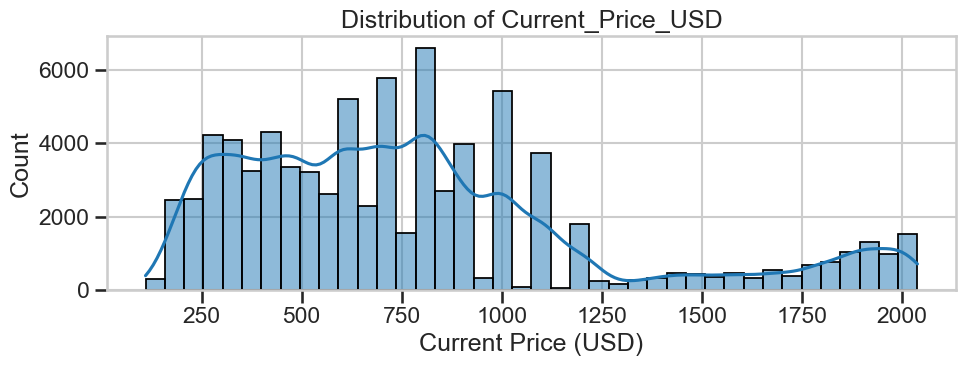

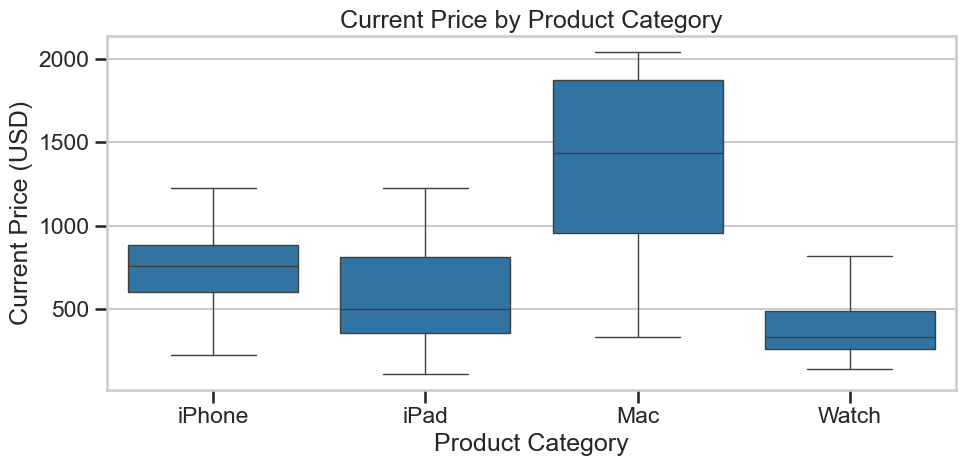

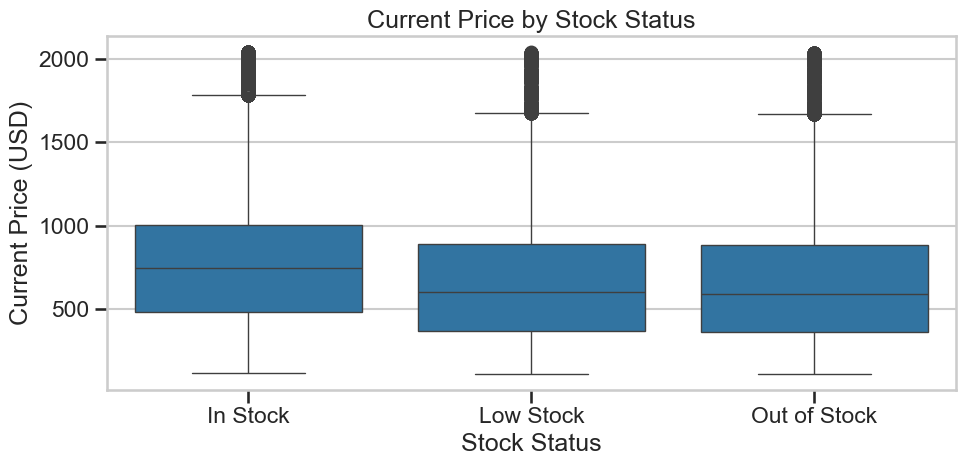

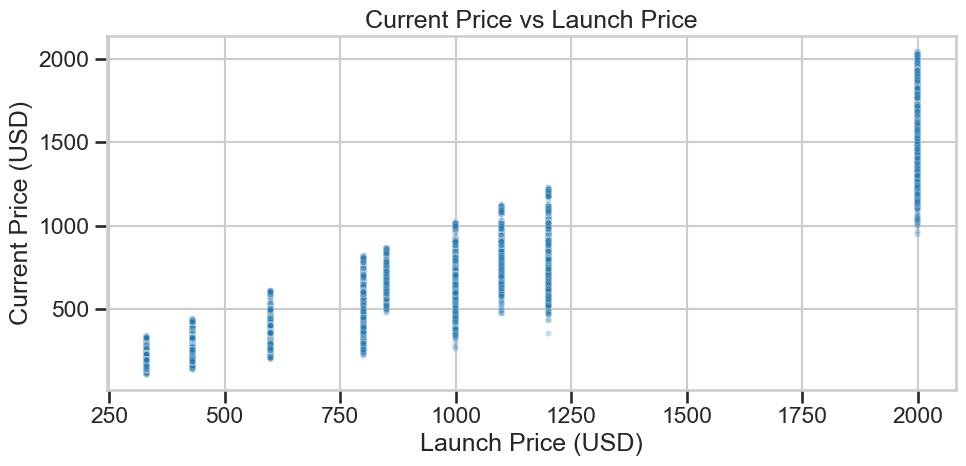

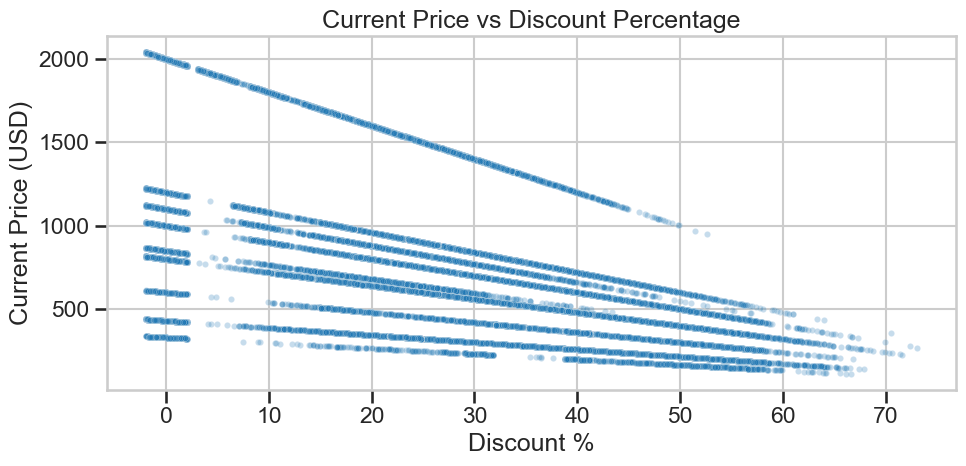

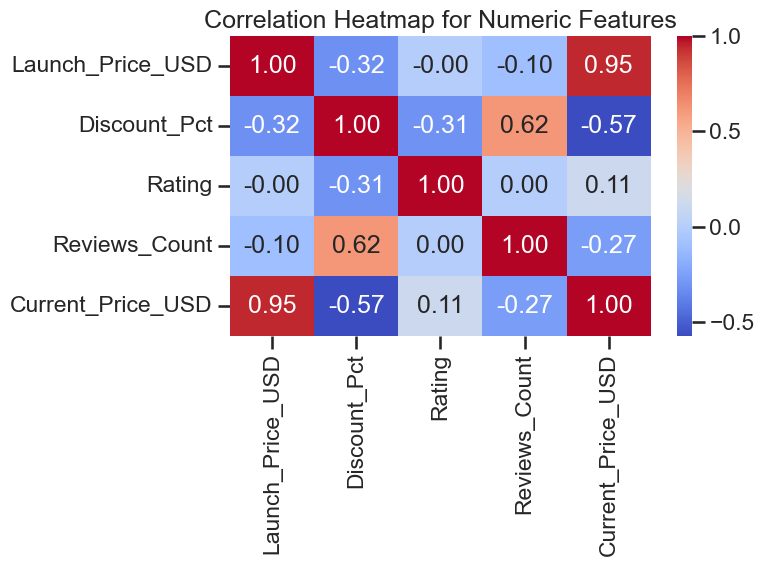


Correlation with Current_Price_USD:
Launch_Price_USD    0.947179
Rating              0.110571
Reviews_Count      -0.265293
Discount_Pct       -0.574824

Average Current_Price_USD by Product Category:
Product_Category
Mac       1382.489812
iPhone     758.674718
iPad       573.083382
Watch      398.638561

Average Current_Price_USD by Platform:
Platform
Amazon      783.968025
Flipkart    781.574259

Average Current_Price_USD by Stock Status:
Stock_Status
In Stock        819.919547
Low Stock       708.515858
Out of Stock    694.365889

Feature selection takeaways:
- Launch_Price_USD is the strongest numeric predictor and should be included as a primary feature.
- Discount_Pct shows a strong negative relationship with current price and is likely useful for modeling.
- Product_Category and Stock_Status capture meaningful price segments and should be encoded for modeling.
- Platform, Condition, and Sale_Event may add signal, but should be tested via feature importance or one-hot encoding.
-

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

# Load data
csv_path = Path('apple_products_pricing_2020_2026.csv')
df = pd.read_csv(csv_path)

# Basic data inspection
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

# Parse date and inspect time span
try:
    df['Date'] = pd.to_datetime(df['Date'])
    print('\nDate range:', df['Date'].min(), 'to', df['Date'].max())
except Exception as e:
    print('Date parsing issue:', e)

# Target overview
target = 'Current_Price_USD'
print(f'\n{target} summary:')
print(df[target].describe().to_string())

# Numeric feature summary
numeric_cols = ['Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count']
print('\nNumeric summary:')
print(df[numeric_cols].describe().T.to_string())

# Quality checks: extreme or suspicious values
print('\nPotential outliers / suspicious values:')
for col in ['Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(flagged)} values outside 1.5*IQR range')

# Categorical distributions
categorical_cols = ['Platform', 'Product_Category', 'Model_Name', 'Condition', 'Stock_Status', 'Sale_Event']
for col in categorical_cols:
    print(f'\nTop values for {col}:')
    print(df[col].value_counts(dropna=False).head(10).to_string())

# Visual 1: target distribution
plt.figure(figsize=(10, 4))
sns.histplot(df[target], bins=40, kde=True)
plt.title('Distribution of Current_Price_USD')
plt.xlabel('Current Price (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Visual 2: boxplot by product category
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Product_Category', y=target, order=['iPhone','iPad','Mac','Watch'])
plt.title('Current Price by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Current Price (USD)')
plt.tight_layout()
plt.show()

# Visual 3: boxplot by stock status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Stock_Status', y=target, order=['In Stock', 'Low Stock', 'Out of Stock'])
plt.title('Current Price by Stock Status')
plt.xlabel('Stock Status')
plt.ylabel('Current Price (USD)')
plt.tight_layout()
plt.show()

# Visual 4: relationship with launch price
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Launch_Price_USD', y=target, alpha=0.25, s=20)
plt.title('Current Price vs Launch Price')
plt.xlabel('Launch Price (USD)')
plt.ylabel('Current Price (USD)')
plt.tight_layout()
plt.show()

# Visual 5: relationship with discount pct
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Discount_Pct', y=target, alpha=0.25, s=20)
plt.title('Current Price vs Discount Percentage')
plt.xlabel('Discount %')
plt.ylabel('Current Price (USD)')
plt.tight_layout()
plt.show()

# Visual 6: heatmap of correlations with target
numeric_for_corr = df[['Launch_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count', target]].copy()
correlation_matrix = numeric_for_corr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Numeric Features')
plt.tight_layout()
plt.show()

# Feature selection notes for modeling
corr_with_target = df[['Launch_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count', target]].corr()[target].drop(target).sort_values(ascending=False)
print('\nCorrelation with Current_Price_USD:')
print(corr_with_target.to_string())

# Grouped means for categorical feature relevance
print('\nAverage Current_Price_USD by Product Category:')
print(df.groupby('Product_Category')[target].mean().sort_values(ascending=False).to_string())
print('\nAverage Current_Price_USD by Platform:')
print(df.groupby('Platform')[target].mean().sort_values(ascending=False).to_string())
print('\nAverage Current_Price_USD by Stock Status:')
print(df.groupby('Stock_Status')[target].mean().sort_values(ascending=False).to_string())

# Suggested modeling features
print('\nFeature selection takeaways:')
print('- Launch_Price_USD is the strongest numeric predictor and should be included as a primary feature.')
print('- Discount_Pct shows a strong negative relationship with current price and is likely useful for modeling.')
print('- Product_Category and Stock_Status capture meaningful price segments and should be encoded for modeling.')
print('- Platform, Condition, and Sale_Event may add signal, but should be tested via feature importance or one-hot encoding.')
print('- Rating has weak linear correlation with price and may be less useful as a standalone feature, though it can still contribute in interactions.')
